In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Auto.csv"

In [3]:
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (392, 9)

First 5 rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0          8         350.0         165    3693          11.5    70   
2  18.0          8         318.0         150    3436          11.0    70   
3  16.0          8         304.0         150    3433          12.0    70   
4  17.0          8         302.0         140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [4]:
# Convert horsepower to numeric
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Remove missing values
df = df.dropna()

# Remove unnecessary column
if "name" in df.columns:
    df = df.drop("name", axis=1)

In [5]:
# Separate features and target
X = df.drop("mpg", axis=1)
y = df["mpg"]

# Convert categorical columns if present
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Models
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )
}

In [7]:
results = []


# Train and evaluate models
for name, model in models.items():

    start_time = time.time()

    model.fit(X_train, y_train)

    training_time = time.time() - start_time

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_r2 = r2_score(y_train, train_prediction)
    test_r2 = r2_score(y_test, test_prediction)

    mae = mean_absolute_error(y_test, test_prediction)
    rmse = np.sqrt(mean_squared_error(y_test, test_prediction))

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "Test R2": test_r2,
        "Train R2": train_r2,
        "Training Time (sec)": training_time
    })


# Results table
results_df = pd.DataFrame(results)

print("\n================ MODEL COMPARISON ================")
print(results_df.to_string(index=False))


# Model complexity
print("\n================ MODEL COMPLEXITY ================")

linear_model = models["Linear Regression"].named_steps["model"]
tree_model = models["Decision Tree"]
forest_model = models["Random Forest"]

print("\nLinear Regression")
print("Number of coefficients:", len(linear_model.coef_))

print("\nDecision Tree")
print("Tree depth:", tree_model.get_depth())
print("Number of nodes:", tree_model.tree_.node_count)
print("Number of leaves:", tree_model.get_n_leaves())

print("\nRandom Forest")
print("Number of trees:", forest_model.n_estimators)

tree_depths = [
    tree.tree_.max_depth
    for tree in forest_model.estimators_
]

total_nodes = sum(
    tree.tree_.node_count
    for tree in forest_model.estimators_
)

print("Average tree depth:", np.mean(tree_depths))
print("Total nodes in forest:", total_nodes)


================ MODEL COMPARISON ================
            Model      MAE     RMSE  Test R2  Train R2  Training Time (sec)
Linear Regression 2.419780 3.272746 0.790150  0.826002             0.046164
    Decision Tree 2.303246 3.307201 0.785708  0.930744             0.008940
    Random Forest 1.708835 2.375982 0.889396  0.979872             0.316825

================ MODEL COMPLEXITY ================

Linear Regression
Number of coefficients: 7

Decision Tree
Tree depth: 5
Number of nodes: 57
Number of leaves: 29

Random Forest
Number of trees: 100
Average tree depth: 10.0
Total nodes in forest: 29198


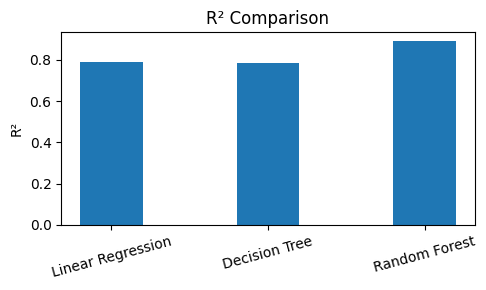

In [11]:
plt.figure(figsize=(5, 3))
plt.bar(results_df["Model"], results_df["Test R2"], width=0.4)
plt.title("R² Comparison")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

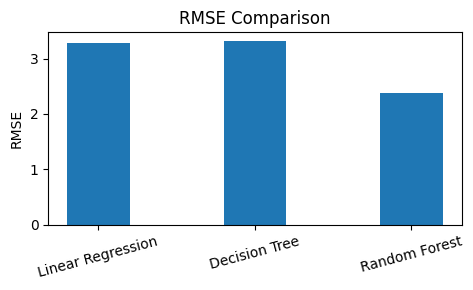

In [12]:
plt.figure(figsize=(5, 3))
plt.bar(results_df["Model"], results_df["RMSE"], width=0.4)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

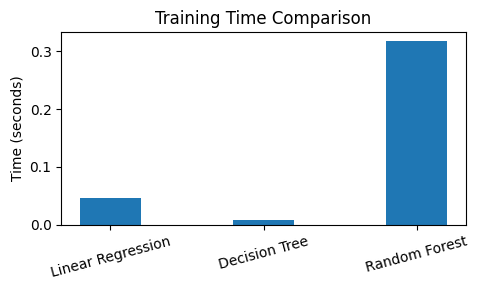

In [13]:
plt.figure(figsize=(5, 3))
plt.bar(results_df["Model"], results_df["Training Time (sec)"], width=0.4)
plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()